In [9]:
import sys
sys.path.append('..')

In [24]:
import numpy as np
from math import log
from tqdm import tqdm
 
from algorithms.Welsch import AlphaDivergenceAlgo
from algorithms.Huber import HuberAlgo
from algorithms.help_functions import generate_linear_model, grid_search_cv_tukey,grid_search_cv_hampel
import statsmodels.api as sm
from statsmodels.robust.norms import TukeyBiweight
from sklearn.model_selection import KFold, train_test_split
from statsmodels.robust.robust_linear_model import RLM
from statsmodels.robust.norms import Hampel
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Break Down point

## General Setup for the break down point experiments

In [ ]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1_000
OUTLIER_SCALE =10000000
DELTA = 0.01
NUM_REPETITIONS = 5_000
EPSILON_RANGE = np.arange(0.0, 0.11, 0.01)
MAX_ITER = 100
SEED = 100
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES

## Monte Carlo Experminets

### Welsch

In [18]:
break_down_Welsch= []
 
for epsilon in EPSILON_RANGE:
    tau = tau_base + epsilon
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = AlphaDivergenceAlgo(X, y)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_Welsch.append((epsilon, bias))

epsilon=0.10: 100%|██████████| 100/100 [00:05<00:00, 17.98it/s]


### Huber

In [ ]:
break_down_huber = []
 
for epsilon in EPSILON_RANGE:
    squared_errors = []
    beta_hats = []
    
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        gamma = 1/(log(1 / DELTA) / N_SAMPLES + epsilon)
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=MAX_ITER)
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_huber.append((epsilon, bias))


epsilon=0.10: 100%|██████████| 100/100 [00:03<00:00, 32.04it/s]


### Tukey’s biweight

In [ ]:
break_down_tukey = []
c_values=np.arange(0.5, 5.5, 0.5)
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Tukey constant on validation set
        best_c = grid_search_cv_tukey(
            X_val, y_val, c_values,
            n_splits=5
        )
 
        # Refit on training set with best parameters
        rlm_model = sm.RLM(y_train, X_train, M=TukeyBiweight(c=best_c))
        beta_hat = rlm_model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_tukey.append((epsilon, bias))
 

Running epsilon=0.00


epsilon=0.00: 100%|██████████| 100/100 [00:33<00:00,  2.94it/s]


Running epsilon=0.01


epsilon=0.01: 100%|██████████| 100/100 [00:39<00:00,  2.51it/s]


Running epsilon=0.02


...

epsilon=0.08: 100%|██████████| 100/100 [00:38<00:00,  2.62it/s]


Running epsilon=0.09


epsilon=0.09: 100%|██████████| 100/100 [00:39<00:00,  2.56it/s]


Running epsilon=0.10


epsilon=0.10: 100%|██████████| 100/100 [00:39<00:00,  2.51it/s]


### Hampel’s three-part

In [53]:
break_down_hampel = []
A_VALUES = [1.5, 2.0, 2.5,3,3.5,4.0]
B_VALUES = [3.0, 4.0, 5.0,6.0,7.0,8.0]
C_VALUES = [6.0, 8.0, 10.0,12.0,14.0,15.0]
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.1, shuffle=True, random_state=rep
        )
 
        # Tune Hampel constants on validation set
        best_params = grid_search_cv_hampel(
            X_val, y_val, A_VALUES, B_VALUES, C_VALUES,
            n_splits=5, random_state=rep,
        )
 
        # Refit on training set with best parameters
        model = RLM(y_train, X_train, M=Hampel(**best_params))
        beta_hat = model.fit().params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_hampel.append((epsilon, bias))

Running epsilon=0.00


epsilon=0.00:  63%|██████▎   | 63/100 [02:26<01:25,  2.32s/it]


KeyboardInterrupt: 

### Quantile Regression

In [28]:
break_down_quantile_1 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.1).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_1.append((epsilon, bias))

Running epsilon=0.00


epsilon=0.00: 100%|██████████| 100/100 [00:04<00:00, 24.90it/s]


Running epsilon=0.01


epsilon=0.01: 100%|██████████| 100/100 [00:04<00:00, 20.90it/s]


Running epsilon=0.02


...

epsilon=0.08: 100%|██████████| 100/100 [00:04<00:00, 21.20it/s]


Running epsilon=0.09


epsilon=0.09: 100%|██████████| 100/100 [00:04<00:00, 22.44it/s]


Running epsilon=0.10


epsilon=0.10: 100%|██████████| 100/100 [00:05<00:00, 19.30it/s]


In [43]:
break_down_quantile_5 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.5).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_5.append((epsilon, bias))

Running epsilon=0.00


epsilon=0.00: 100%|██████████| 100/100 [00:03<00:00, 25.50it/s]


Running epsilon=0.01


epsilon=0.01: 100%|██████████| 100/100 [00:04<00:00, 24.97it/s]


Running epsilon=0.02


...

epsilon=0.08: 100%|██████████| 100/100 [00:04<00:00, 21.68it/s]


Running epsilon=0.09


epsilon=0.09: 100%|██████████| 100/100 [00:04<00:00, 24.35it/s]


Running epsilon=0.10


epsilon=0.10: 100%|██████████| 100/100 [00:05<00:00, 19.98it/s]


In [38]:
break_down_quantile_9 = []
 
for epsilon in EPSILON_RANGE:
    print(f"Running epsilon={epsilon:.2f}")
    squared_errors = []
    beta_hats = []
 
    for rep in tqdm(range(NUM_REPETITIONS), desc=f"epsilon={epsilon:.2f}"):
        y, X, _ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=epsilon,
        )
 
        model = sm.QuantReg(y, X)
        beta_hat = model.fit(q=0.9).params
 
        beta_hats.append(beta_hat)
        squared_errors.append(np.linalg.norm(beta_star - beta_hat) ** 2)
 
    bias = np.linalg.norm(beta_star - np.mean(beta_hats, axis=0))
    break_down_quantile_9.append((epsilon, bias))

Running epsilon=0.00


epsilon=0.00: 100%|██████████| 100/100 [00:03<00:00, 30.06it/s]


Running epsilon=0.01


epsilon=0.01: 100%|██████████| 100/100 [00:03<00:00, 25.33it/s]


Running epsilon=0.02


...

epsilon=0.08: 100%|██████████| 100/100 [00:04<00:00, 24.48it/s]


Running epsilon=0.09


epsilon=0.09: 100%|██████████| 100/100 [00:04<00:00, 24.38it/s]


Running epsilon=0.10


epsilon=0.10: 100%|██████████| 100/100 [00:03<00:00, 26.39it/s]


## Plots

Since the above experiments take long time we provide the results we got in the folder results_break_down_points

### Downloading Data

In [54]:
break_Welsch= pd.read_csv('./break_down_points/break_down_exp_Welsch.csv')

In [55]:
break_down_huber=pd.read_csv('./break_down_points/break_down_exp_Hube.csv')

In [56]:
break_down_tukey=pd.read_csv('./break_down_points/break_down_exp_tukey.csv', sep=';')

In [57]:
break_down_hampel=pd.read_csv('./break_down_points/break_down_exp_Hampel.csv',sep=';')

In [58]:
break_down_quantile_1=pd.read_csv('./break_down_points/break_down_exp_quantile_reg_q_1.csv')

In [59]:
break_down_quantile_5=pd.read_csv('./break_down_points/break_down_exp_quantile_regression_q_5.csv')

In [60]:
break_down_quantile_9=pd.read_csv('./break_down_points/break_down_exp_quantile_regression_q_9.csv')

### Turning Data to data frames 

In [61]:
break_down_Welsch_df = pd.DataFrame(break_Welsch, columns=['delta', 'Error'])

In [62]:
break_down_huber_df = pd.DataFrame(break_down_huber,columns=['delta', 'Error'])

In [63]:
break_down_tukey_df = pd.DataFrame(break_down_tukey, columns=['delta', 'Error'])

In [64]:
break_down_hampel_df = pd.DataFrame(break_down_hampel, columns=['delta', 'Error'])

In [65]:
break_down_quantile_1_df = pd.DataFrame(break_down_quantile_1, columns=['delta', 'Error'])

In [66]:
break_down_quantile_5_df = pd.DataFrame(break_down_quantile_5, columns=['delta', 'Error'])

In [67]:
break_down_quantile_9_df = pd.DataFrame(break_down_quantile_9, columns=['delta', 'Error'])

### Comparison of the Euclidean norm of the bias of the Welsch estimator against other robust estimators.

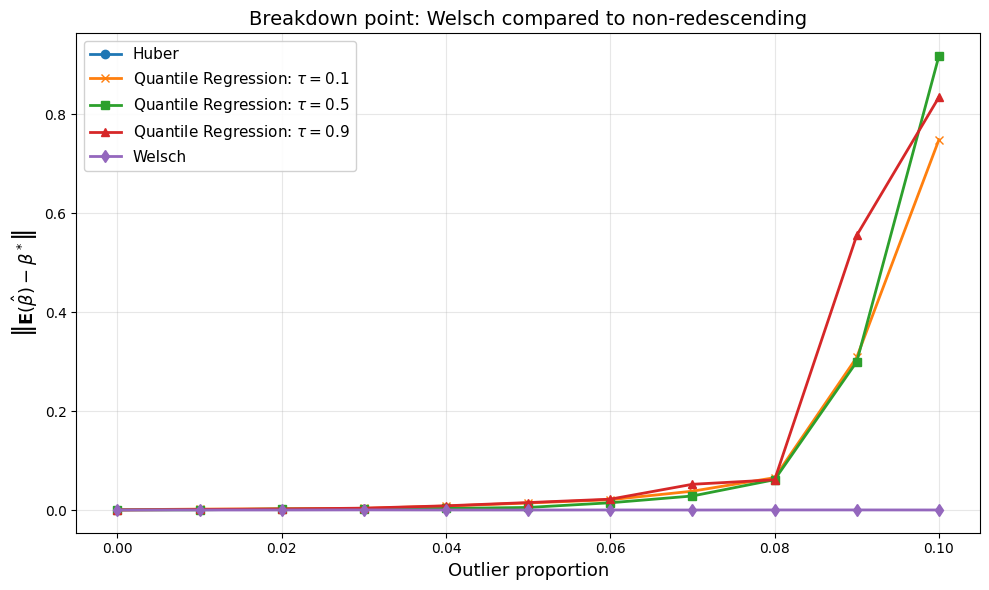

In [68]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_huber_df['delta'], break_down_huber_df['Error'],
         label='Huber', marker='o', linewidth=2)
plt.plot(break_down_quantile_1_df['delta'], break_down_quantile_1_df['Error'],
         label=r'Quantile Regression: $\tau=0.1$', marker='x', linewidth=2)
plt.plot(break_down_quantile_5_df['delta'], break_down_quantile_5_df['Error'],
         label=r'Quantile Regression: $\tau=0.5$', marker='s', linewidth=2)
plt.plot(break_down_quantile_9_df['delta'], break_down_quantile_9_df['Error'],
         label=r'Quantile Regression: $\tau=0.9$', marker='^', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to non-redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

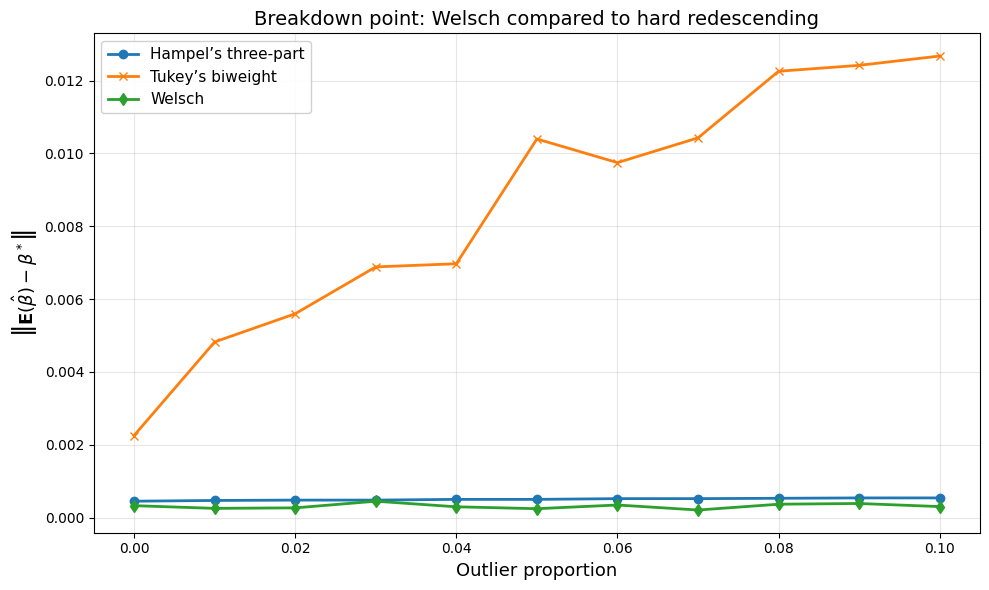

In [69]:
plt.figure(figsize=(10, 6))

plt.plot(break_down_hampel_df['delta'], break_down_hampel_df['Error'],
         label='Hampel’s three-part', marker='o', linewidth=2)
plt.plot(break_down_tukey_df['delta'], break_down_tukey_df['Error'],
         label='Tukey’s biweight', marker='x', linewidth=2)
plt.plot(break_down_Welsch_df['delta'], break_down_Welsch_df['Error'],
         label='Welsch', marker='d', linewidth=2)

plt.xlabel('Outlier proportion', fontsize=13)
plt.ylabel(r'$\left\| \mathbf{E}(\hat{\beta}) - \beta^* \right\|$', fontsize=13)
plt.title('Breakdown point: Welsch compared to hard redescending', fontsize=14)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mean Square Error

### Huber VS Welsch

#### General Setup

In [43]:
N_SAMPLES = 10_000
P_FEATURES = 10
BETA_SCALE = 1_000
OUTLIER_SCALE =10_000
DELTA = 0.01
NUM_REPETITIONS = 5_000
EPSILON_RANGE = np.arange(0.0, 0.11, 0.01)
MAX_ITER = 100
SEED = 100
 
np.random.seed(SEED)
beta_star = BETA_SCALE * np.random.choice([-1, 1], size=P_FEATURES)
tau_base = log(1 / DELTA) / N_SAMPLES
per_outliers=0.1

##### Welsch

In [44]:
MSE_Welsch=[]
for rep in tqdm(range(NUM_REPETITIONS), desc="MSE Welsch:"):
        tau = tau_base + per_outliers
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
 
        model = AlphaDivergenceAlgo(X, y)
        beta_hat = model.optimizer_approach(tau=tau, maxiter=MAX_ITER)
 
        MSE_Welsch.append(np.linalg.norm(beta_star - beta_hat) ** 2)

MSE Welsch:: 100%|██████████| 5000/5000 [04:25<00:00, 18.86it/s]


##### Huber

In [45]:
MSE_huber= []
 

for rep in tqdm(range(NUM_REPETITIONS), desc="MSE Huber: "):
        gamma =1/( log(1 / DELTA) / N_SAMPLES + per_outliers)
        y,X,_ = generate_linear_model(
            N_SAMPLES,
            P_FEATURES,
            beta_star,
            seed=rep,
            outliers=True,
            outlier_const=OUTLIER_SCALE,
            noise_type="pareto",
            outliers_perc=per_outliers,
        )
        model = HuberAlgo(X, y)
        beta_hat, _ = model.optimizer_approach(gamma=gamma, max_iter=1000)
 
        MSE_huber.append(np.linalg.norm(beta_star - beta_hat) ** 2)


MSE Huber: 100%|██████████| 5000/5000 [01:53<00:00, 44.20it/s]


##### Histogram

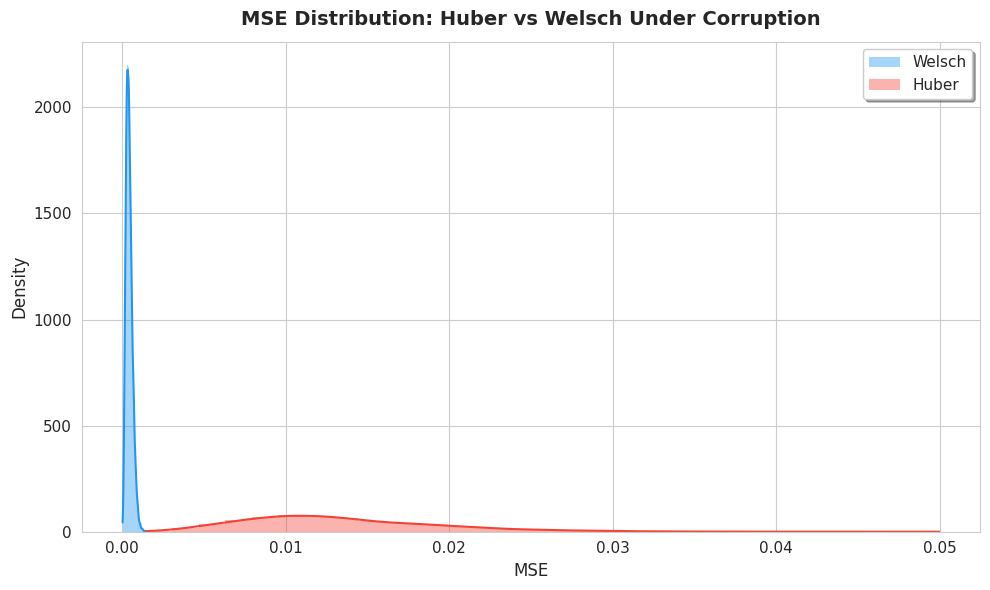

In [48]:

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))


sns.histplot(MSE_Welsch, bins=30, kde=True, color='#2196F3', label='Welsch',
             stat='density', alpha=0.4, edgecolor='none', linewidth=2)
sns.histplot(MSE_huber, bins=30, kde=True, color='#F44336', label='Huber',
             stat='density', alpha=0.4, edgecolor='none', linewidth=2)


plt.title('MSE Distribution: Huber vs Welsch Under Corruption',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('MSE', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True)
plt.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

### Welsch VS Redecenders

#### General Setup